In [50]:
import glob
import numpy as np
import pandas as pd

import logomaker as lm

from tangermeme.io import read_meme

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set scanpy and matplotlib styles for publication
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [55]:
condition_colors = {
    "control": "#B0B0B0",
    "3-cyt": "#7acce6",
    "IFNg": "#FF7F50",
    "Ex-4_HG": "#90EE90",
    "palmitate": "#BA55D3",
}
celltype_colors = {
    "SC.beta": "#2a9df4",
    "SC.alpha": "#967bb6",
    "SC.EC": "#ff7f50",
    "SC.delta": "#dc143c"
}
celltype_order = ["SC.alpha", "SC.beta", "SC.EC"]
condition_order = ["control", "3-cyt", "IFNg", "Ex-4_HG", "palmitate"]

In [2]:
path_motif_file = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/motifs/meme/combined.meme"

In [3]:
motif_dict = read_meme(path_motif_file)
motifs = list(motif_dict.items())

In [4]:
names = np.array([m[0] for m in motifs], dtype="U")

In [5]:
path_counts = glob.glob("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/*/fold_0/chrombpnet/1.0/marginalization/marginalization_data.counts.npz")
path_counts = [p for p in path_counts if "SC.delta" not in p]
len(path_counts)

15

In [6]:
# Repeat the above for all counts files and make one long dataframe
dfs = []
for path in path_counts:
    model = path.split("/")[-6]
    counts_ = np.load(path)
    c_before = counts_['c_before'].squeeze()
    c_after = counts_['c_after'].squeeze()
    c_diff = c_after - c_before
    c_diff_mean = np.mean(c_diff, axis=-1)

    df = pd.DataFrame({
        "name": names,
        "c_diff_mean": c_diff_mean,
        "model": model,
        "celltype": model.split("_")[0],
        "condition": model.split("_")[1],
    })
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(by="c_diff_mean", ascending=False)
df

,name,c_diff_mean,model,celltype,condition
112,Average_1117,1.863630,SC.alpha_palmitate,SC.alpha,palmitate
367,Average_1117,1.840434,SC.alpha_3-cyt,SC.alpha,3-cyt
163,Average_1117,1.831772,SC.EC_IFNg,SC.EC,IFNg
571,Average_1117,1.811907,SC.alpha_control,SC.alpha,control
10,Average_1117,1.782585,SC.beta_Ex-4_HG,SC.beta,Ex-4
...,...,...,...,...,...
230,Average_1180,-0.007433,SC.EC_control,SC.EC,control
485,Average_1180,-0.008689,SC.beta_palmitate,SC.beta,palmitate
2,Average_1040,-0.010538,SC.beta_Ex-4_HG,SC.beta,Ex-4
208,Average_1047,-0.012269,SC.EC_control,SC.EC,control


In [ ]:
path_motif_annotation = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/motifs/tfs_initial.txt"
initial_motifs = pd.read_csv(path_motif_annotation, sep="\t", header=None)
initial_motifs.columns = ["cluster_name", "top_tomtom_annotation", "evalue"]
annotation_dict = initial_motifs.set_index("cluster_name")["top_tomtom_annotation"].to_dict()

In [8]:
df = df.merge(initial_motifs, left_on="name", right_on="cluster_name", how="left")
df

,name,c_diff_mean,model,celltype,condition,cluster_name,top_tomtom_annotation,evalue
0,Average_1117,1.863630,SC.alpha_palmitate,SC.alpha,palmitate,Average_1117,HNF1B_HUMAN.H11MO.0.A,8.221290e-07
1,Average_1117,1.840434,SC.alpha_3-cyt,SC.alpha,3-cyt,Average_1117,HNF1B_HUMAN.H11MO.0.A,8.221290e-07
2,Average_1117,1.831772,SC.EC_IFNg,SC.EC,IFNg,Average_1117,HNF1B_HUMAN.H11MO.0.A,8.221290e-07
3,Average_1117,1.811907,SC.alpha_control,SC.alpha,control,Average_1117,HNF1B_HUMAN.H11MO.0.A,8.221290e-07
4,Average_1117,1.782585,SC.beta_Ex-4_HG,SC.beta,Ex-4,Average_1117,HNF1B_HUMAN.H11MO.0.A,8.221290e-07
...,...,...,...,...,...,...,...,...
760,Average_1180,-0.007433,SC.EC_control,SC.EC,control,Average_1180,HNF4A_nuclearreceptor_1,1.855730e-01
761,Average_1180,-0.008689,SC.beta_palmitate,SC.beta,palmitate,Average_1180,HNF4A_nuclearreceptor_1,1.855730e-01
762,Average_1040,-0.010538,SC.beta_Ex-4_HG,SC.beta,Ex-4,Average_1040,NFKB1_HUMAN.H11MO.1.B,3.978460e-07
763,Average_1047,-0.012269,SC.EC_control,SC.EC,control,Average_1047,IRF1_MOUSE.H11MO.0.A,2.099920e-11


In [9]:
# Create a metadata df for the models
metadata = df[["model", "celltype", "condition"]].drop_duplicates()
metadata

,model,celltype,condition
0,SC.alpha_palmitate,SC.alpha,palmitate
1,SC.alpha_3-cyt,SC.alpha,3-cyt
2,SC.EC_IFNg,SC.EC,IFNg
3,SC.alpha_control,SC.alpha,control
4,SC.beta_Ex-4_HG,SC.beta,Ex-4
5,SC.beta_IFNg,SC.beta,IFNg
6,SC.EC_Ex-4_HG,SC.EC,Ex-4
7,SC.alpha_Ex-4_HG,SC.alpha,Ex-4
9,SC.beta_3-cyt,SC.beta,3-cyt
10,SC.EC_palmitate,SC.EC,palmitate


In [10]:
# turn into a matrix of shape (n_motifs, n_models)
matrix = df.pivot(index="name", columns="model", values="c_diff_mean")

# Z-score the df across models
matrix_z = (matrix - matrix.mean(axis=1).values[:, np.newaxis]) / matrix.std(axis=1).values[:, np.newaxis]

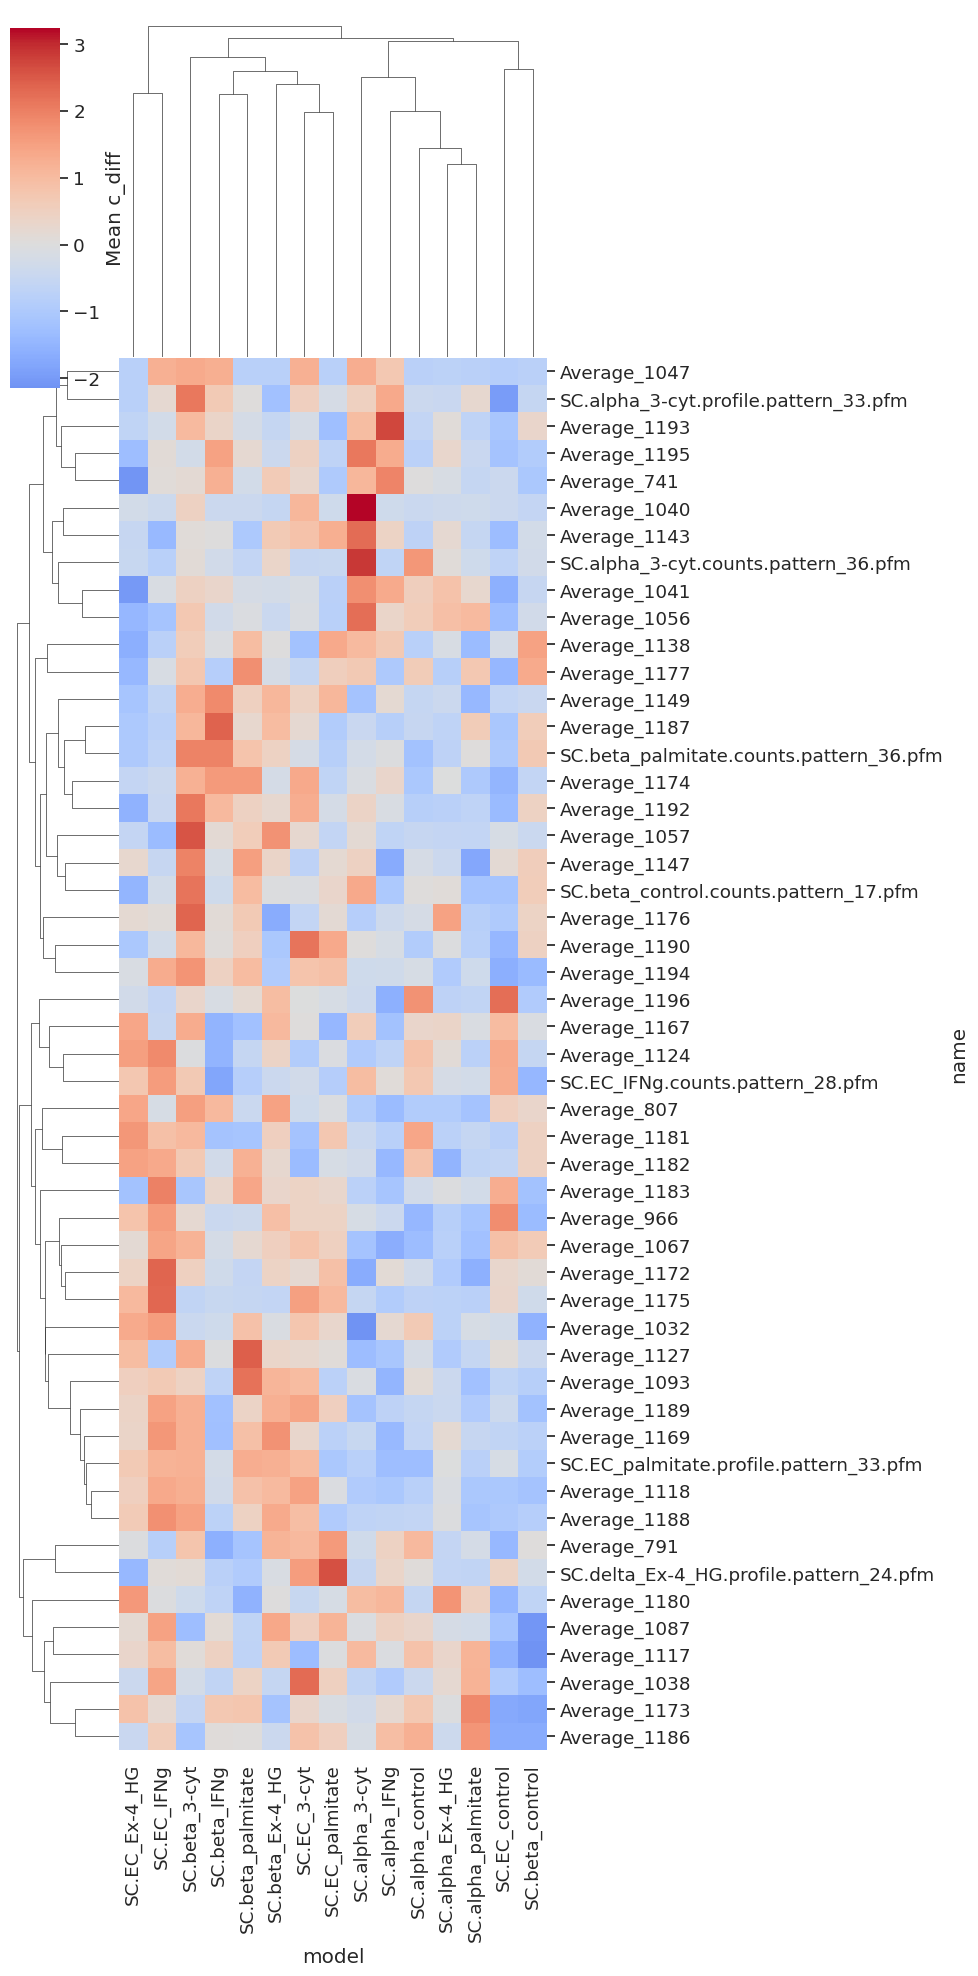

In [11]:
# Clustermap of the matrix
sns.set_theme(style="white", font_scale=1.2)
g = sns.clustermap(
    matrix_z,
    cmap="coolwarm",
    center=0,
    figsize=(10, 20),
    row_cluster=True,
    col_cluster=True,
    cbar_kws={"label": "Mean c_diff"},
)

In [12]:
# Run a simple ANOVA for each motif across conditions
# Then follow up with post-hoc dunn tests for pairwise comparisons

# Get the unique conditions
conditions = df["condition"].unique()

# Create a dictionary to hold the results
anova_results_condition = []
tukey_results_condition = []

for name in df["name"].unique():

    # Get the data for this motif
    motif_data = df[df["name"] == name]

    # Perform ANOVA
    anova_result = f_oneway(*[group["c_diff_mean"].values for name, group in motif_data.groupby("condition")])
    anova_results_condition.append({
        "motif": name,
        "F": anova_result.statistic,
        "pvalue": anova_result.pvalue
    })

    # If ANOVA is significant, perform Tukey's HSD test
    if anova_result.pvalue < 0.1:
        tukey_result = pairwise_tukeyhsd(motif_data["c_diff_mean"], motif_data["condition"])
        table_data = tukey_result.summary().data[1:]
        column_headers = tukey_result.summary().data[0]
        tukey_df = pd.DataFrame(table_data, columns=column_headers)
        tukey_df["motif"] = name
        tukey_results_condition.append(tukey_df)

# Convert results to DataFrames
anova_df_condition = pd.DataFrame(anova_results_condition)
tukey_df_condition = pd.concat(tukey_results_condition)

In [13]:
tukey_df_condition[tukey_df_condition["motif"] == "Average_1167"]

,group1,group2,meandiff,p-adj,lower,upper,reject,motif
0,3-cyt,Ex-4,0.0294,0.9687,-0.1270,0.1858,False,Average_1167
1,3-cyt,IFNg,-0.1673,0.0350,-0.3237,-0.0109,True,Average_1167
2,3-cyt,control,-0.0226,0.9879,-0.1790,0.1338,False,Average_1167
3,3-cyt,palmitate,-0.1522,0.0573,-0.3086,0.0042,False,Average_1167
4,Ex-4,IFNg,-0.1967,0.0135,-0.3531,-0.0404,True,Average_1167
5,Ex-4,control,-0.0520,0.8054,-0.2084,0.1044,False,Average_1167
6,Ex-4,palmitate,-0.1816,0.0220,-0.3380,-0.0252,True,Average_1167
7,IFNg,control,0.1447,0.0732,-0.0117,0.3011,False,Average_1167
8,IFNg,palmitate,0.0151,0.9974,-0.1413,0.1715,False,Average_1167
9,control,palmitate,-0.1296,0.1190,-0.2860,0.0268,False,Average_1167


In [14]:
# Do the same thing for celltype
celltypes = df["celltype"].unique()

anova_results_celltype = []
tukey_results_celltype = []

for name in df["name"].unique():

    # Get the data for this motif
    motif_data = df[df["name"] == name]

    # Perform ANOVA
    anova_result = f_oneway(*[group["c_diff_mean"].values for name, group in motif_data.groupby("celltype")])
    anova_results_celltype.append({
        "motif": name,
        "F": anova_result.statistic,
        "pvalue": anova_result.pvalue
    })

    # If ANOVA is significant, perform Tukey's HSD test
    if anova_result.pvalue < 0.1:
        tukey_result = pairwise_tukeyhsd(motif_data["c_diff_mean"], motif_data["celltype"])
        table_data = tukey_result.summary().data[1:]
        column_headers = tukey_result.summary().data[0]
        tukey_df = pd.DataFrame(table_data, columns=column_headers)
        tukey_df["motif"] = name
        tukey_results_celltype.append(tukey_df)

# Convert results to DataFrames
anova_df_celltype = pd.DataFrame(anova_results_celltype)
tukey_df_celltype = pd.concat(tukey_results_celltype)

In [15]:
# compile the significant motifs into a single dataframe
anova_df_condition["test"] = "condition"
anova_df_celltype["test"] = "celltype"
significant_motifs = pd.concat([anova_df_condition, anova_df_celltype], ignore_index=True)
significant_motifs = significant_motifs[significant_motifs["pvalue"] < 0.1]
significant_motifs = significant_motifs.groupby("motif").agg({
    "test": lambda x: ", ".join(x),
    "F": "mean",
    "pvalue": "mean"
}).reset_index()
significant_motifs = significant_motifs.sort_values(by="pvalue")
significant_motifs

,motif,test,F,pvalue
2,Average_1047,condition,170.835201,3.699696e-09
12,Average_1175,celltype,30.220369,2.066285e-05
5,Average_1067,celltype,29.970552,2.153897e-05
24,SC.beta_palmitate.counts.pattern_36.pfm,celltype,17.347369,2.880579e-04
3,Average_1056,celltype,14.179684,6.909098e-04
19,Average_807,celltype,10.715524,2.138885e-03
14,Average_1187,celltype,10.554436,2.266841e-03
1,Average_1041,celltype,10.305391,2.482677e-03
20,Average_966,celltype,8.941992,4.192339e-03
10,Average_1167,condition,7.301998,5.099245e-03


# Plot profiles

In [16]:
path_profiles = glob.glob("/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/*/fold_0/chrombpnet/1.0/marginalization/marginalization_data.profiles.npz")

In [17]:
profile_ = np.load(path_profiles[0])
p_before = profile_['p_before'].squeeze()
p_after = profile_['p_after'].squeeze()
p_diff = p_after - p_before
p_diff.shape

(51, 1000)

In [18]:
# Get a nested dict of the profiles for each model and motif
profiles = {}
for path in path_profiles:
    model = path.split("/")[-6]
    # If SC.delta is in the model name, skip it
    if "SC.delta" in model:
        continue
    profiles[model] = {}
    profile_ = np.load(path)
    p_diff = profile_['p_diff'].squeeze()
    for i, name in enumerate(names):
        profiles[model][name] = p_diff[i, :]

In [24]:
# Order keys by celltype first, then by condition
new_order = []
for celltype in celltype_order:
    for condition in condition_order:
        key = f"{celltype}_{condition}"
        if key in sig_profiles:
            new_order.append(key)
sig_profiles_ordered = {k: sig_profiles[k] for k in new_order if k in sig_profiles}
sig_profiles_ordered

{'SC.alpha_control': array([-3.13577677e-05,  1.82626992e-05, -3.95854446e-05,  2.05170193e-05,
        -1.09941615e-05, -2.45064251e-05,  3.20321662e-05,  3.06941329e-05,
         4.45384604e-05,  6.28644836e-05,  2.96223223e-05,  4.86610995e-05,
         1.16506985e-04,  1.49532062e-05,  7.19725831e-05,  4.95582587e-05,
         3.65268053e-05,  1.36962771e-04,  1.13204462e-04,  1.22979756e-04,
         1.76148910e-04,  1.72279648e-04,  1.89615152e-04,  1.25132201e-04,
         1.29979293e-04,  1.83972679e-04,  2.38981890e-04,  1.99766711e-04,
         2.63844724e-04,  2.60819688e-04,  2.54459001e-04,  3.39997273e-04,
         2.67192381e-04,  3.28682967e-04,  3.90878113e-04,  2.34949497e-04,
         3.43072753e-04,  3.49341341e-04,  3.38305934e-04,  5.41179027e-04,
         5.19397622e-04,  6.93252535e-04,  5.84186094e-04,  4.34436292e-04,
         4.93962613e-04,  4.69005330e-04,  4.69401415e-04,  3.82971489e-04,
         4.96097456e-04,  6.27906907e-04,  8.34742330e-04,  7.848649

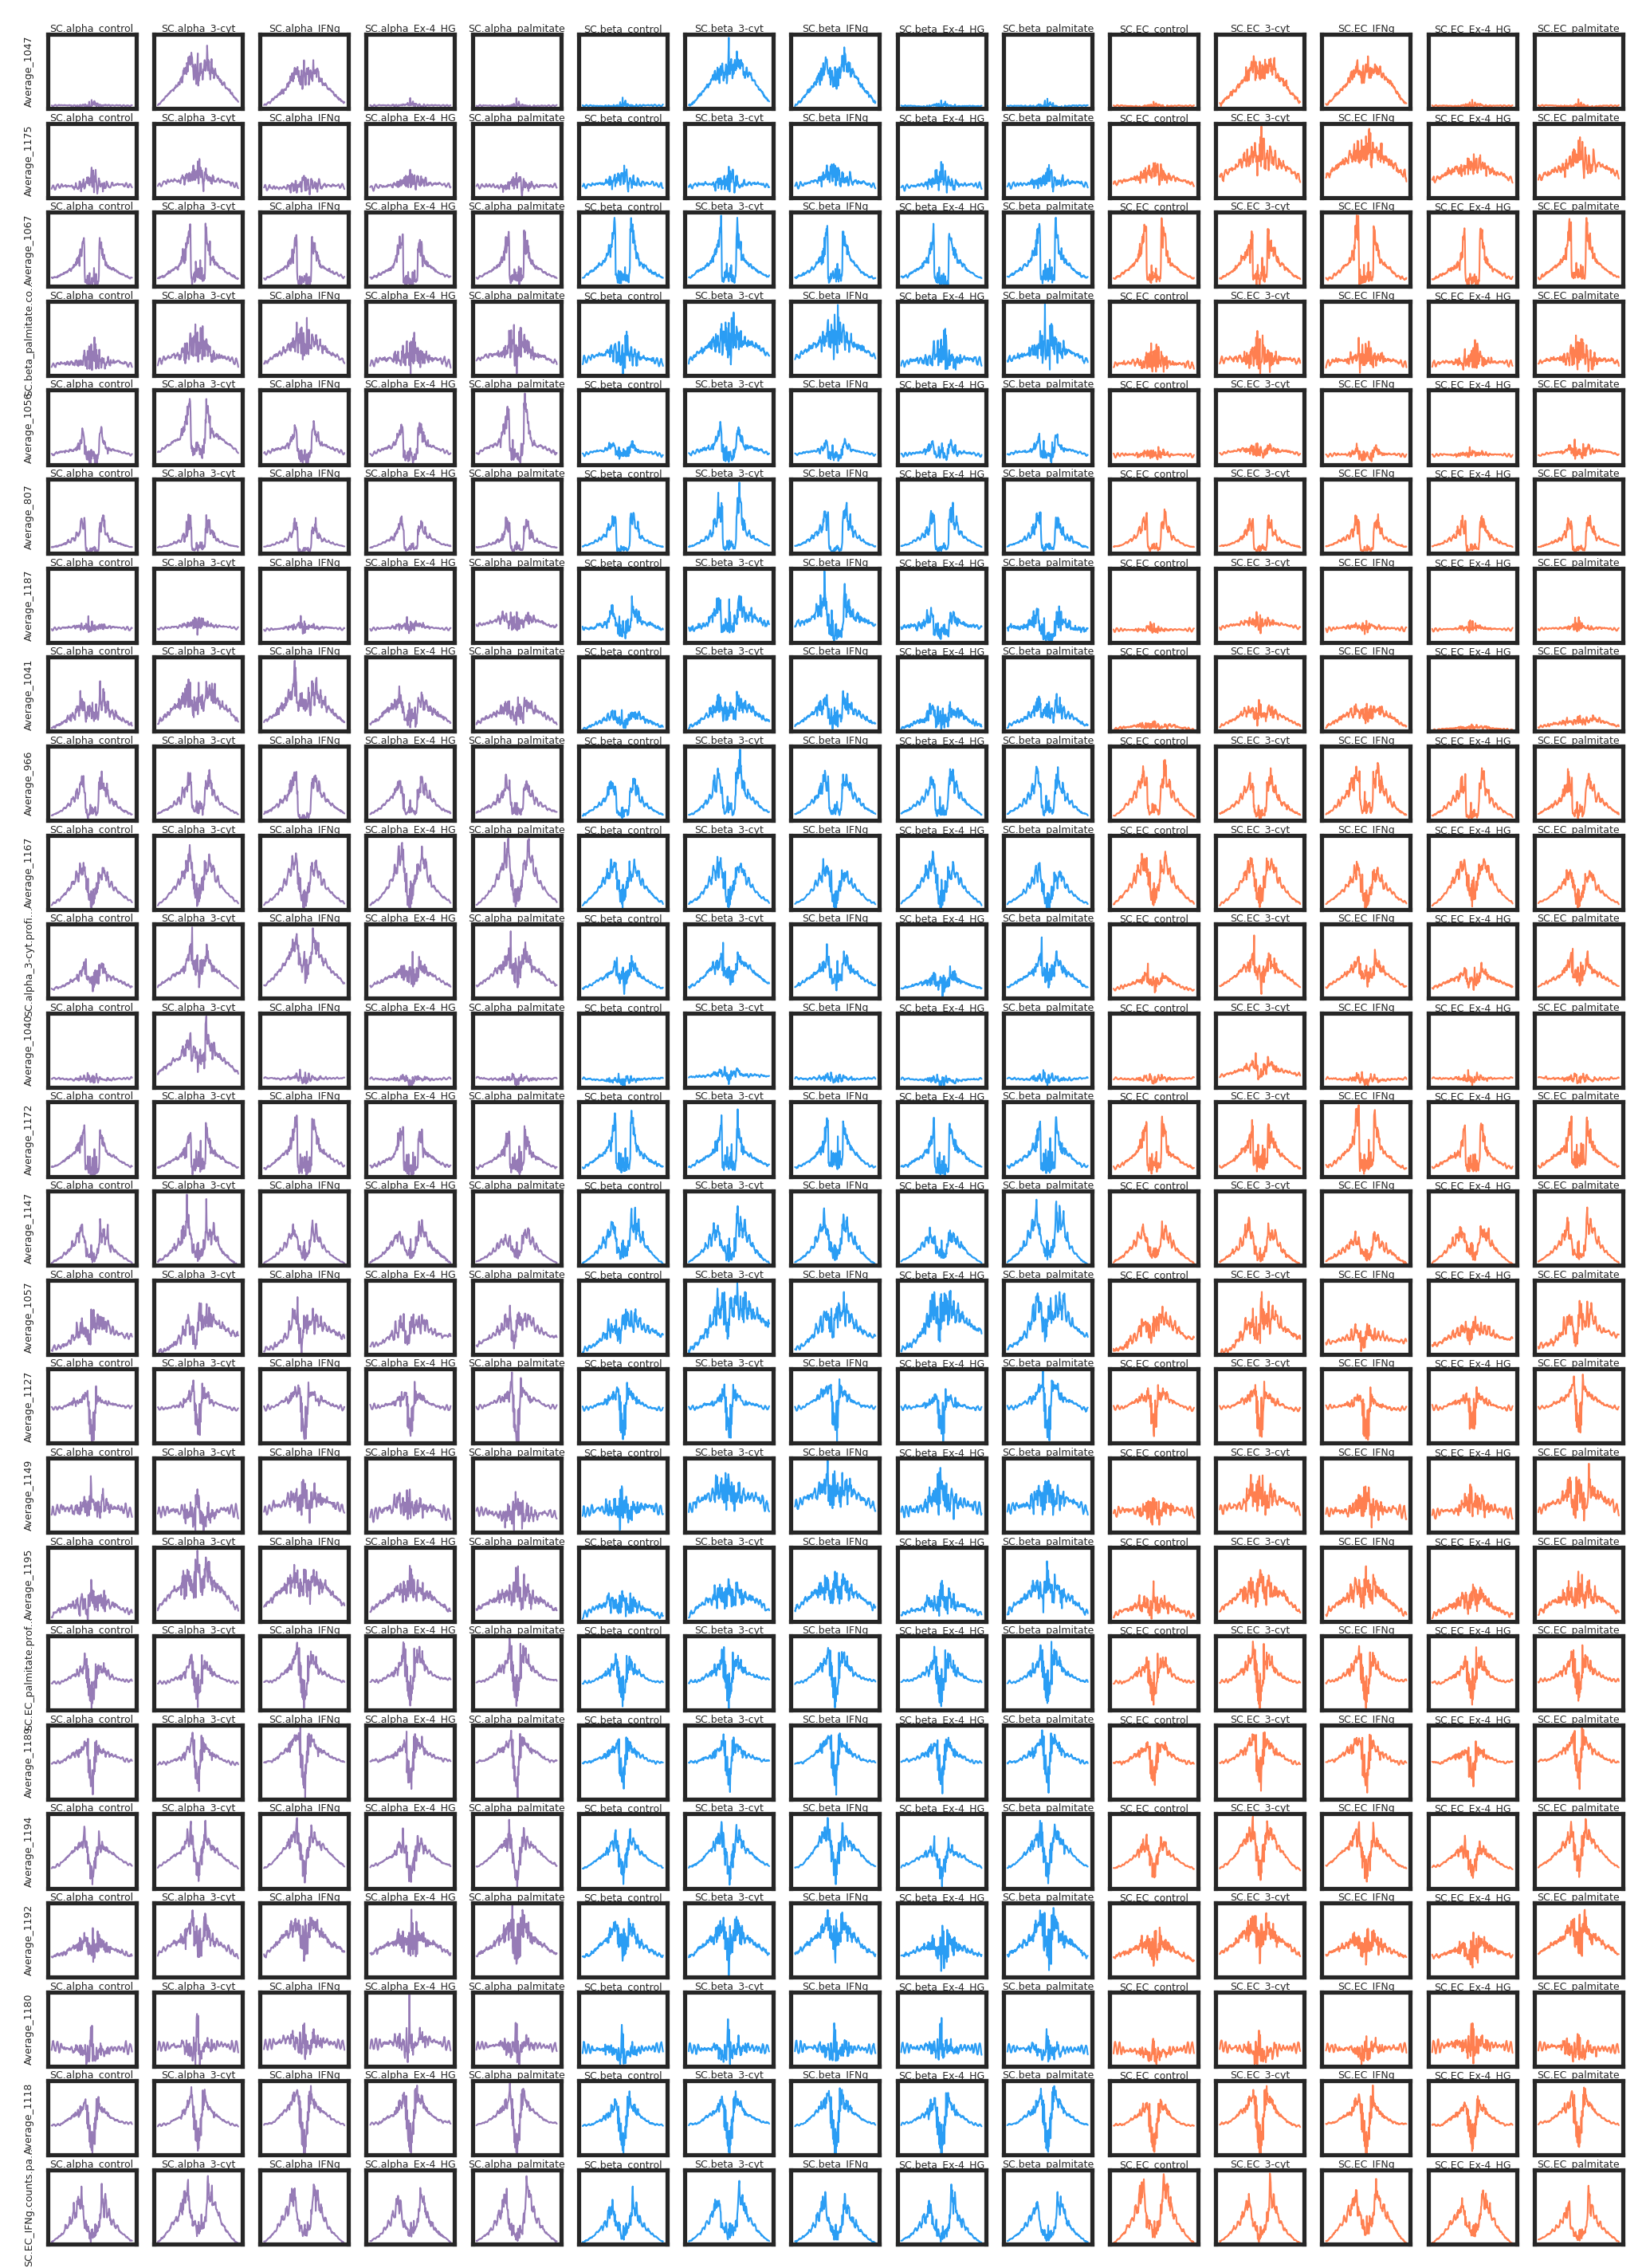

In [25]:
n_sig_motifs = len(significant_motifs)
n_models = len(sig_profiles_ordered)

fig, axes = plt.subplots(nrows=n_sig_motifs, ncols=n_models, figsize=(8.5, n_sig_motifs // 2), dpi=300)
for i in range(n_sig_motifs):

    # Get the motif name
    sig_motif = significant_motifs["motif"].values[i]
    
    # Need to get profiles for the sig_motif across all models
    sig_profiles = {model: profiles[model][sig_motif][400:600] for model in profiles.keys()}

    # Find the ymin and ymax across all profiles
    ymin = np.inf
    ymax = -np.inf
    for model, profile in sig_profiles.items():
        ymin = min(ymin, profile.min())
        ymax = max(ymax, profile.max())
    ymin = -(np.abs(ymin * 0.95) if ymin < 0 else ymin * 0.95)
    ymax = ymax * 1.05

    # Order keys by celltype first, then by condition
    new_order = []
    for celltype in celltype_order:
        for condition in condition_order:
            key = f"{celltype}_{condition}"
            if key in sig_profiles:
                new_order.append(key)
    sig_profiles_ordered = {k: sig_profiles[k] for k in new_order if k in sig_profiles}
    
    # Plot the profiles
    for j, (model, profile) in enumerate(sig_profiles_ordered.items()):
        ax = axes[i, j]
        celltype = model.split("_")[0]
        condition = model.split("_")[1]
        color = celltype_colors[celltype]
        ax.plot(profile, color=color, lw=0.5)
        ax.set_title(model, fontsize=3, pad=0.5)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            sig_motif = sig_motif[:20] + "..." if len(sig_motif) > 20 else sig_motif
            ax.set_ylabel(sig_motif, fontsize=3, rotation=90)

In [28]:
from matplotlib.patheffects import AbstractPathEffect
from matplotlib.textpath import TextPath
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties


class LogoGlyph(AbstractPathEffect):
    def __init__(self, glyph, ref_glyph='E', font_props=None,
                 offset=(0., 0.), **kwargs):

        super().__init__(offset)

        path_orig = TextPath((0, 0), glyph, size=1, prop=font_props)
        dims = path_orig.get_extents()
        ref_dims = TextPath((0, 0), ref_glyph, size=1, prop=font_props).get_extents()

        h_scale = 1 / dims.height
        ref_width = max(dims.width, ref_dims.width)
        w_scale = 1 / ref_width
        w_shift = (1 - dims.width / ref_width) / 2
        x_shift = -dims.x0
        y_shift = -dims.y0
        stretch = (
            Affine2D()
            .translate(tx=x_shift, ty=y_shift)
            .scale(sx=w_scale, sy=h_scale)
            .translate(tx=w_shift, ty=0)
        )

        self.path = stretch.transform_path(path_orig)

        #: The dictionary of keywords to update the graphics collection with.
        self._gc = kwargs

    def draw_path(self, renderer, gc, tpath, affine, rgbFace):
        return renderer.draw_path(gc, self.path, affine, rgbFace)


def plot_logo(ax, heights, glyphs, colors=None, font_props=None, shade_bounds=None):
    if colors is None:
        colors = {g: None for g in glyphs}

    ax.margins(x=0, y=0)
    
    pos_values = np.clip(heights, 0, None)
    neg_values = np.clip(heights, None, 0)
    pos_order = np.argsort(pos_values, axis=0)
    neg_order = np.argsort(neg_values, axis=0)[::-1,:]
    pos_reorder = np.argsort(pos_order, axis=0)
    neg_reorder = np.argsort(neg_order, axis=0)
    pos_offsets = np.take_along_axis(
        np.cumsum(
            np.take_along_axis(pos_values, pos_order, axis=0), axis=0
        ), pos_reorder, axis=0
    )
    neg_offsets = np.take_along_axis(
        np.cumsum(
            np.take_along_axis(neg_values, neg_order, axis=0), axis=0
        ), neg_reorder, axis=0
    )
    bottoms = pos_offsets + neg_offsets - heights

    x = np.arange(heights.shape[1])

    for glyph, height, bottom in zip(glyphs, heights, bottoms):
        ax.bar(x, height, 0.95, bottom=bottom, 
               path_effects=[LogoGlyph(glyph, font_props=font_props)], color=colors[glyph])

    if shade_bounds is not None:
        start, end = shade_bounds
        ax.axvspan(start - 0.5, end - 0.5, color='0.9', zorder=-1)

    ax.axhline(zorder=-1, linewidth=0.5, color='black')


LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {"A": '#109648', "C": '#255C99', "G": '#F7B32B', "T": '#D62839'}
LOGO_FONT = FontProperties(weight="bold")

In [29]:
selected_motifs = [
    "Average_1124",  # CTCF general accessibility
    "Average_1047",  # IRF in inflammation (control vs 3-cyt and IFNg)
    "Average_1175",  # EC cell type specific
    "Average_1187",  # Beta cell specific
    "Average_1056",  # Cell type and 3-cyt specific
    "Average_1041",  # Cell type specific in alpha
    "Average_807",   # Similar across most conditions, except SC.beta_3-cyt
    "Average_966",   # Very similar to 807
    #"Average_MEFD2", # Interesting
    "Average_1040",  # Pretty cool
    "Average_1193",  # Maybe
    #"Average_NDF1_HUMAN.H11MO.0.A"  # SC > alpha 3-cyt specific
]

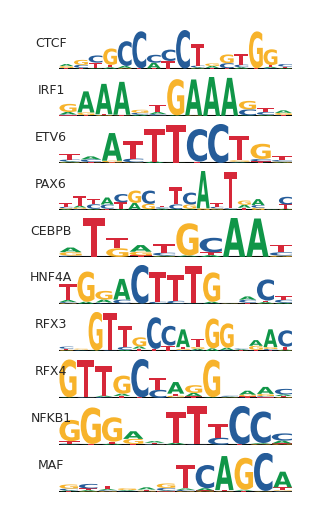

In [37]:
# Set the number of motifs
n_motifs = len(selected_motifs)

# Create a subplot grid for the logos (one column and n_motifs rows)
fig, axes = plt.subplots(nrows=n_motifs, ncols=1, figsize=(1, 2), dpi=300)

for i in range(n_motifs):

    # Get the motif name
    sig_motif = selected_motifs[i]

    # Plot the logo in each row
    ppm = motif_dict[sig_motif].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    ax_logo = axes[i]
    # Plot logo with logomaker
    lm.Logo(
        lm_df,
        ax=ax_logo,
        color_scheme=LOGO_COLORS,
        fade_below=0.1,
        font_name=LOGO_FONT.get_name(),
    )
    
    # Hide spines
    for name, spine in ax_logo.spines.items():
        spine.set_visible(False)
    
    # Remove ticks
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])

    # Set label for each motif as annotation
    annotation = annotation_dict.get(sig_motif, "Unknown").split("_")[0]
    ax_logo.set_ylabel(annotation, fontsize=3, rotation=0, labelpad=2)

#plt.tight_layout()
plt.show()

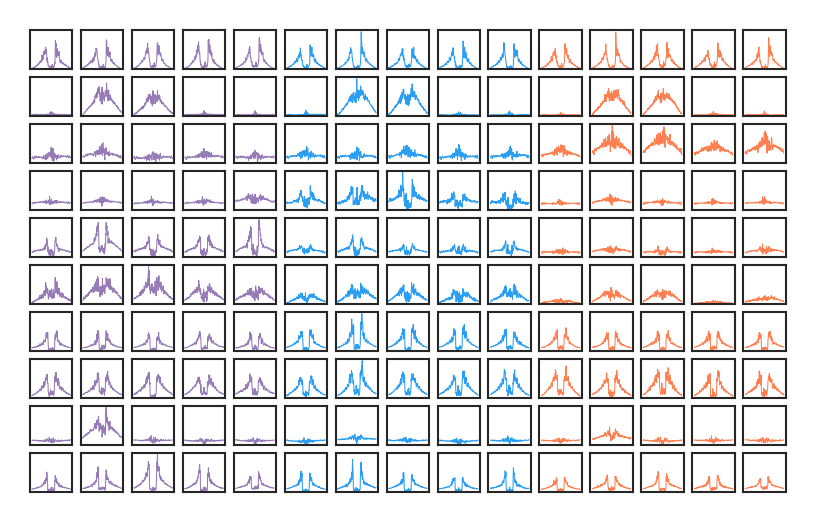

In [30]:
n_motifs = len(selected_motifs)
n_models = len(sig_profiles_ordered)

# Create the subplots with an extra column for logos
fig, axes = plt.subplots(nrows=n_motifs, ncols=n_models, figsize=(3.25, n_motifs // 4), dpi=300)

for i in range(n_motifs):

    # Get the motif name
    sig_motif = selected_motifs[i]

    # Need to get profiles for the sig_motif across all models
    sig_profiles = {model: profiles[model][sig_motif][400:600] for model in profiles.keys()}

    # Find the ymin and ymax across all profiles
    ymin = np.inf
    ymax = -np.inf
    for model, profile in sig_profiles.items():
        ymin = min(ymin, profile.min())
        ymax = max(ymax, profile.max())
    ymin = -(np.abs(ymin * 0.95) if ymin < 0 else ymin * 0.95)
    ymax = ymax * 1.05

    # Order keys by celltype first, then by condition
    new_order = []
    for celltype in celltype_order:
        for condition in condition_order:
            key = f"{celltype}_{condition}"
            if key in sig_profiles:
                new_order.append(key)
    sig_profiles_ordered = {k: sig_profiles[k] for k in new_order if k in sig_profiles}
    
    # Plot the profiles in the remaining columns (i.e., column 1 to n_models)
    for j, (model, profile) in enumerate(sig_profiles_ordered.items()):
        ax = axes[i, j]
        celltype = model.split("_")[0]
        condition = model.split("_")[1]
        color = celltype_colors[celltype]
        ax.plot(profile, color=color, lw=0.25)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([])
        ax.set_yticks([])

plt.show()


/tmp/ipykernel_1338091/1084611033.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


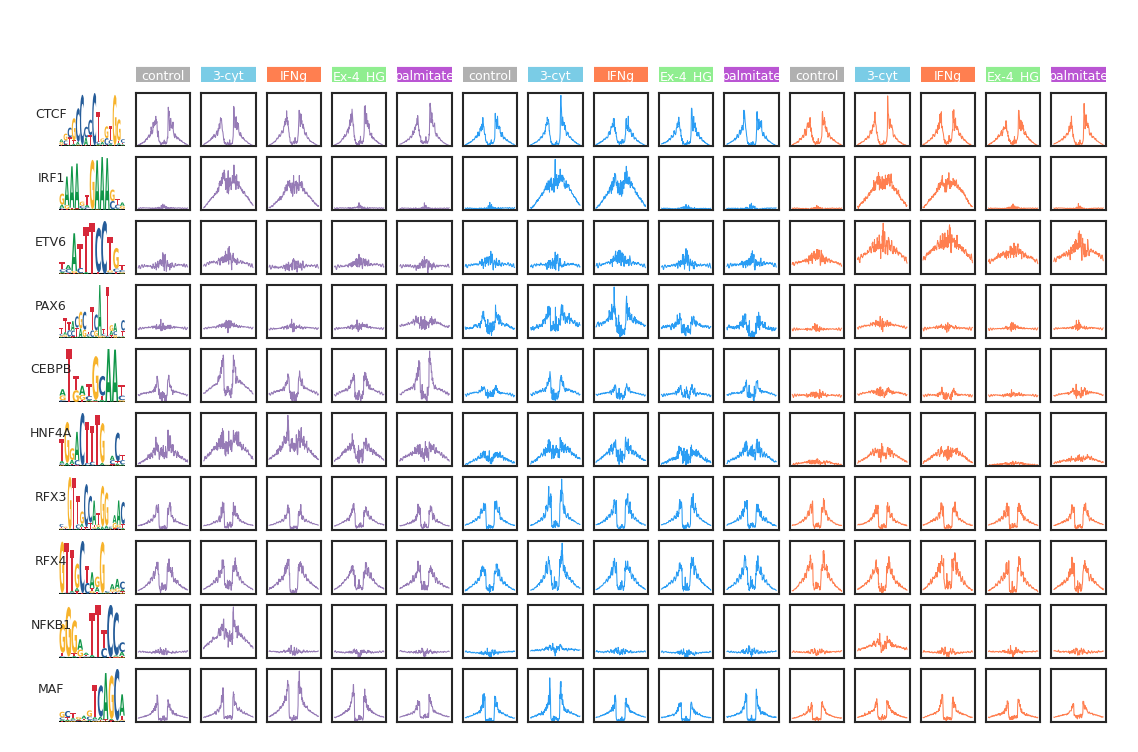

In [60]:
# Set the number of motifs
n_motifs = len(selected_motifs)
n_models = len(sig_profiles_ordered)

# Create the figure and GridSpec layout for logos + profiles
fig = plt.figure(figsize=(4.5, 3), dpi=300)

# Create a GridSpec layout with one extra row for the titles
gs = gridspec.GridSpec(n_motifs + 1, n_models + 1, width_ratios=[1.2] + [1] * n_models, wspace=0.2)

# Add colored rectangles with text above the plots (except the first column)
condition_order = list(condition_colors.keys())  # Ensure we are using condition colors correctly

for j in range(1, n_models + 1):  # Start from the second column (to exclude the motif column)
    ax_title = fig.add_subplot(gs[0, j])  # Create subplot for title (first row)
    condition_index = (j - 1) % len(condition_order)  # Loop through conditions dynamically
    condition = condition_order[condition_index]  # Get the condition for this column
    
    # Create a colored rectangle based on the condition
    ax_title.add_patch(patches.Rectangle(
        (0, 0), 1.5, 0.25, transform=ax_title.transAxes, color=condition_colors[condition], zorder=10
    ))
    
    # Add the condition name as text inside the rectangle (white text)
    ax_title.text(0.5, 0.125, condition, ha='center', va='center', fontsize=3, color='white', zorder=11)
    
    # Remove axes and ticks for the title subplot
    ax_title.axis('off')

# Plot logos and profiles (from row 1 onward)
for i in range(n_motifs):
    sig_motif = selected_motifs[i]
    
    # Create subplot for the logo in the first column
    ax_logo = fig.add_subplot(gs[i + 1, 0])  # Start from row 1 (i + 1)
    
    # Get the motif data for plotting the logo
    ppm = motif_dict[sig_motif].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability',
        to_type='information',
    )
    # Plot logo with logomaker
    lm.Logo(
        lm_df,
        ax=ax_logo,
        color_scheme=LOGO_COLORS,
        fade_below=0.1,
        font_name=LOGO_FONT.get_name(),
    )
    
    # Hide spines for the logos
    for name, spine in ax_logo.spines.items():
        spine.set_visible(False)
    
    # Remove ticks for the logos
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])
    
    # Set label for each motif as annotation
    annotation = annotation_dict.get(sig_motif, "Unknown").split("_")[0]
    ax_logo.set_ylabel(annotation, fontsize=3, rotation=0, labelpad=2)

    # Plot profiles in the remaining columns (except the first)
    sig_profiles = {model: profiles[model][sig_motif][400:600] for model in profiles.keys()}

    # Find the ymin and ymax across all profiles
    ymin = np.inf
    ymax = -np.inf
    for model, profile in sig_profiles.items():
        ymin = min(ymin, profile.min())
        ymax = max(ymax, profile.max())
    ymin = -(np.abs(ymin * 0.95) if ymin < 0 else ymin * 0.95)
    ymax = ymax * 1.05

    # Order keys by celltype first, then by condition
    new_order = []
    for celltype in celltype_order:
        for condition in condition_order:
            key = f"{celltype}_{condition}"
            if key in sig_profiles:
                new_order.append(key)
    sig_profiles_ordered = {k: sig_profiles[k] for k in new_order if k in sig_profiles}
    
    # Plot the profiles in the remaining columns (i.e., column 1 to n_models)
    for j, (model, profile) in enumerate(sig_profiles_ordered.items()):
        ax = fig.add_subplot(gs[i + 1, j + 1])  # Skip the first column (logos)
        celltype = model.split("_")[0]
        condition = model.split("_")[1]
        color = celltype_colors[celltype]
        ax.plot(profile, color=color, lw=0.25)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Make axes thinner for non-motif plots
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)  # Make axes thinner

plt.tight_layout()
plt.savefig('/cellar/users/aklie/projects/igvf/ChromBetaNet/figures/Fig5/Fig5d.pdf', bbox_inches='tight', dpi=300)
plt.show()

# DONE!

---